In [1]:
# Step 1: Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ensure the TensorFlow version is 2.x
print(f'TensorFlow version: {tf.__version__}')


TensorFlow version: 2.16.2


In [2]:
# Step 2: Load and preprocess data
def load_data(file_path):
    with open(file_path, 'r') as file:
        text = file.read()
    sentences = text.split('. ')
    return sentences

# Example usage

# sentences = load_data('text.txt')
sentences = load_data('metamorphosis_clean.txt')
# sentences = load_data('FinalCleanGermanParagraphs.txt')
print(f'First 5 sentences: {sentences[:5]}')


First 5 sentences: ['\ufeffOne morning, when Gregor Samsa woke from troubled dreams, he found\nhimself transformed in his bed into a horrible vermin', ' He lay on\nhis armour-like back, and if he lifted his head a little he could\nsee his brown belly, slightly domed and divided by arches into stiff\nsections', ' The bedding was hardly able to cover it and seemed ready\nto slide off any moment', ' His many legs, pitifully thin compared\nwith the size of the rest of him, waved about helplessly as he\nlooked.\n\n"What\'s happened to me?" he thought', " It wasn't a dream"]


In [3]:
# Step 3: Preprocess the sentences
def preprocess_data(sentences):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(sentences)
    sequences = tokenizer.texts_to_sequences(sentences)
    vocab_size = len(tokenizer.word_index) + 1
    return sequences, tokenizer, vocab_size

# Example usage
sequences, tokenizer, vocab_size = preprocess_data(sentences)
print(f'Sequences (first 5): {sequences[:5]}')
print(f'Vocabulary size: {vocab_size}')
print(f'Word index (first 10): {dict(list(tokenizer.word_index.items())[:10])}')


Sequences (first 5): [[1313, 139, 55, 14, 93, 935, 28, 1314, 936, 4, 241, 42, 1315, 10, 5, 112, 49, 12, 721, 1316], [4, 159, 25, 5, 1317, 84, 45, 3, 33, 4, 447, 5, 85, 12, 69, 4, 29, 81, 5, 589, 722, 345, 1318, 3, 1319, 64, 1320, 49, 723, 1321], [1, 1322, 7, 201, 133, 2, 1323, 8, 3, 122, 590, 2, 1324, 160, 70, 294], [5, 510, 150, 1325, 937, 1326, 15, 1, 938, 6, 1, 388, 6, 17, 1327, 58, 1328, 13, 4, 113, 295, 212, 2, 193, 4, 98], [8, 511, 12, 939]]
Vocabulary size: 2618
Word index (first 10): {'the': 1, 'to': 2, 'and': 3, 'he': 4, 'his': 5, 'of': 6, 'was': 7, 'it': 8, 'had': 9, 'in': 10}


In [4]:
# Step 4: Prepare data for training using TensorFlow Dataset API for memory efficiency
def prepare_data_for_training(sequences, vocab_size, n_steps=5):
    xs = []
    ys = []
    
    for seq in sequences:
        for i in range(n_steps, len(seq)):
            xs.append(seq[i-n_steps:i])
            ys.append(seq[i])
    
    xs = tf.constant(xs, dtype=tf.int32)
    ys = tf.constant(ys, dtype=tf.int32)
    
    dataset = tf.data.Dataset.from_tensor_slices((xs, ys))
    dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Example usage
dataset = prepare_data_for_training(sequences, vocab_size)
for data, label in dataset.take(1):
    print(f'Data shape: {data.shape}')
    print(f'Label shape: {label.shape}')
    print(f'Data: {data.numpy()[:5]}')
    print(f'Label: {label.numpy()[:5]}')


Data shape: (32, 5)
Label shape: (32,)
Data: [[1313  139   55   14   93]
 [ 139   55   14   93  935]
 [  55   14   93  935   28]
 [  14   93  935   28 1314]
 [  93  935   28 1314  936]]
Label: [ 935   28 1314  936    4]


2024-07-15 00:49:39.694023: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
# Step 5: Create and compile the model
def create_model(vocab_size, n_steps=5):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=100, input_length=n_steps),  # Embedding layer to handle integer indices
        LSTM(100, activation='relu', return_sequences=True),
        LSTM(100, activation='relu'),
        Dense(vocab_size, activation='softmax')
    ])
    
    model.compile(
        loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy for integer labels
        optimizer=tf.keras.optimizers.Adam(0.01),
        metrics=['accuracy']
    )
    
    model.build(input_shape=(None, n_steps))
    
    return model

# Example usage
model = create_model(vocab_size)
model.summary()


/Users/julian.lopeshinz/Development/own/thl/deep learning/ea3/newenv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train dataset size: 481
Validation dataset size: 120
Train Data shape: (32, 5)
Train Label shape: (32,)
Train Data: [[1313  139   55   14   93]
 [ 139   55   14   93  935]
 [  55   14   93  935   28]
 [  14   93  935   28 1314]
 [  93  935   28 1314  936]]
Train Label: [ 935   28 1314  936    4]
Epoch 1/10


2024-07-15 00:49:39.758394: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-07-15 00:49:39.789984: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-07-15 00:49:39.816526: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-07-15 00:49:39.820850: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0489 - loss: 6.4895 - val_accuracy: 0.0673 - val_loss: 6.2159
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0561 - loss: 5.8085 - val_accuracy: 0.0642 - val_loss: 6.5568
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0655 - loss: 5.6539 - val_accuracy: 0.0783 - val_loss: 6.4302
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0845 - loss: 5.5406 - val_accuracy: 0.0843 - val_loss: 6.4157
Epoch 5/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0890 - loss: 5.4845 - val_accuracy: 0.0820 - val_loss: 6.5938
Epoch 6/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0934 - loss: 5.3936 - val_accuracy: 0.0856 - val_loss: 6.7485
Epoch 7/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0980 - loss: 5.3335 - val_accuracy: 0.0851 - val_loss: 6.6605
Epoch 8/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1028 - loss: 5.2531 - val_accuracy: 0.086

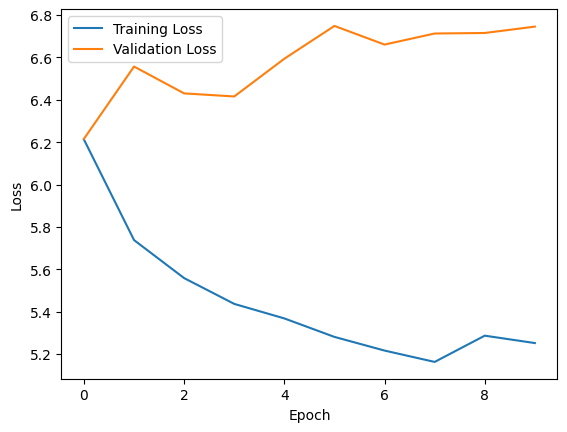

In [6]:
# Step 6: Train the model with progress visualization
def plot_training_history(history):
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def train_model_with_progress(model, train_dataset, val_dataset, epochs):
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs
    )
    return history

# Example usage
# Split the dataset into training and validation datasets
dataset_size = len(list(dataset))
val_size = int(0.2 * dataset_size)
train_size = dataset_size - val_size

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

# Debugging: Ensure datasets are not empty
print(f'Train dataset size: {len(list(train_dataset))}')
print(f'Validation dataset size: {len(list(val_dataset))}')

for data, label in train_dataset.take(1):
    print(f'Train Data shape: {data.shape}')
    print(f'Train Label shape: {label.shape}')
    print(f'Train Data: {data.numpy()[:5]}')
    print(f'Train Label: {label.numpy()[:5]}')

history = train_model_with_progress(model, train_dataset, val_dataset, epochs=10)
plot_training_history(history)

In [7]:
# Step 7: Predict the next word
def predict_next_words(model, tokenizer, input_text, top_k=3):
    sequence = tokenizer.texts_to_sequences([input_text.split()])[-1]
    sequence = pad_sequences([sequence], maxlen=1)
    sequence = tf.constant(sequence, dtype=tf.int32)
    prediction = model.predict(sequence)
    top_indices = np.argsort(prediction[0])[::-1][:top_k]
    
    predicted_words = []
    for index in top_indices:
        for word, word_index in tokenizer.word_index.items():
            if word_index == index:
                predicted_words.append(word)
    
    return predicted_words

# Example usage
input_text = "What's happened to"
next_words = predict_next_words(model, tokenizer, input_text)
print(f'Next word prediction: {next_words}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Next word prediction: ['be', 'been', 'have']


In [8]:
model.save('model.keras')

In [9]:
import json

# Save the tokenizer's word index to a JSON file
word_index = tokenizer.word_index
with open('word_index.json', 'w') as f:
    json.dump(word_index, f)


In [10]:
# Step 8: Export the model as TensorFlow.js model
import tensorflowjs as tfjs

# Specify the path where you want to save the model
export_path = 'tfjs_model'

# Save the model
tfjs.converters.save_keras_model(model, export_path)

print(f'Model exported to {export_path}')


ModuleNotFoundError: No module named 'tensorflow_decision_forests'